In [ ]:
import unicodedata
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_excel('ICB_Dados_Desagregados.xlsx')

print(df.head())

print(df.info())

  Data_Coleta   Estab Produto Marca  Preco  Quantidade    PPK
0  2022-09-23  MD_020   Carne     0  54.20         1.0  54.20
1  2022-09-12  MB_040   Carne     0  53.90         1.0  53.90
2  2022-09-21  MC_030   Carne     0  53.90         1.0  53.90
3  2022-09-23  ME_010   Carne     0  51.99         1.0  51.99
4  2022-09-12  MB_060   Carne     0  51.90         1.0  51.90
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27170 entries, 0 to 27169
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Data_Coleta  27170 non-null  datetime64[ns]
 1   Estab        27170 non-null  object        
 2   Produto      27170 non-null  object        
 3   Marca        27170 non-null  object        
 4   Preco        27170 non-null  float64       
 5   Quantidade   27170 non-null  float64       
 6   PPK          27170 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 1.5+ MB
None


In [ ]:
print(df.isnull().sum())

print(df[df['Marca'] == '0'].groupby('Produto').size())

Data_Coleta    0
Estab          0
Produto        0
Marca          0
Preco          0
Quantidade     0
PPK            0
dtype: int64
Series([], dtype: int64)


In [ ]:
df.describe()

,Data_Coleta,Preco,Quantidade,PPK
count,27170,27170.000000,27170.000000,27170.000000
mean,2023-12-09 11:29:37.872653568,13.317797,1.340549,19.015638
min,2022-09-12 00:00:00,1.190000,0.200000,0.741667
25%,2023-04-19 00:00:00,5.980000,0.900000,5.550000
50%,2023-12-13 00:00:00,8.990000,1.000000,7.580000
75%,2024-07-19 00:00:00,17.690000,1.000000,29.980000
max,2025-03-21 00:00:00,999.000000,12.000000,999.000000
std,NaN,11.558083,1.437605,22.649794


In [ ]:
estatisticas = df.groupby('Produto')[['Preco','PPK']].agg(['mean', 'median', 'min', 'max'])
estatisticas.head(21)

Preco                               PPK             \
                       mean  median    min     max       mean     median   
Produto                                                                    
Arroz             29.337414  28.990   4.75   47.99   5.885831   5.798000   
Açúcar             4.466395   4.390   2.98   22.20   4.463002   4.390000   
Banana Nanica      7.941429   6.565   2.19  999.00   7.941429   6.565000   
Banana Prata      10.282568   9.990   2.99   19.90  10.282568   9.990000   
Batata             6.985434   6.990   1.98   31.90   6.985434   6.990000   
Café              19.683460  18.990   6.89   45.90  39.350760  37.980000   
Carne             41.824960  42.390  19.90   57.99  41.824960  42.390000   
Carne Acem        38.422963  37.990  29.90   48.29  38.422963  37.990000   
Carne Coxão Mole  48.632143  48.445  34.70   59.99  48.632143  48.445000   
Carne Pernil      22.563929  23.990  12.90   32.79  22.563929  23.990000   
Farinha            6.083392   5.990   2.49   13.99   6.083392   5.990000   
Feijão             8.536725   8.600   1.19   13.75   8.536725   8.600000   
Frango Peito      24.546667  23.950  12.99   35.19  24.546667  23.950000   
Frango Sobrecoxa  15.530370  15.900   9.90   26.99  15.530370  15.900000   
Leite              5.395171   5.280   2.98   10.99   5.395171   5.280000   
Macarrão           4.575075   4.290   2.99    9.29   9.150149   8.580000   
Manteiga          14.045770  13.890   3.15   41.90  68.335613  68.450000   
Ovo               13.265000  13.190   8.90   19.08   1.105417   1.099167   
Pão               16.054691  15.980   3.90   26.50  16.054691  15.980000   
Tomate             8.705095   8.990   2.95   16.99   8.705095   8.990000   
Óleo               7.124027   6.990   3.99   17.99   7.914160   7.766667   

                                         
                        min         max  
Produto                                  
Arroz              1.118000    9.598000  
Açúcar             2.980000   22.200000  
Banana Nanica      2.190000  999.000000  
Banana Prata       2.990000   19.900000  
Batata             1.980000   31.900000  
Café              13.780000   91.800000  
Carne             19.900000   57.990000  
Carne Acem        29.900000   48.290000  
Carne Coxão Mole  34.700000   59.990000  
Carne Pernil      12.900000   32.790000  
Farinha            2.490000   13.990000  
Feijão             1.190000   13.750000  
Frango Peito      12.990000   35.190000  
Frango Sobrecoxa   9.900000   26.990000  
Leite              2.980000   10.990000  
Macarrão           5.980000   18.580000  
Manteiga          12.720000  147.500000  
Ovo                0.741667    1.590000  
Pão                3.900000   26.500000  
Tomate             2.950000   16.990000  
Óleo               4.433333   19.988889

In [ ]:
def corrigir_preco_banana(df, limite_preco=20, limite_ppk=20):
    df['Data_Coleta'] = pd.to_datetime(df['Data_Coleta'], errors='coerce')
    df['AnoMes'] = df['Data_Coleta'].dt.to_period('M')

    filtro_preco = (df['Produto'] == 'Banana Nanica') & (df['Preco'] > limite_preco)
    for idx in df.loc[filtro_preco].index:
        periodo = df.loc[idx, 'AnoMes']
        filtro_validos = (df['Produto'] == 'Banana Nanica') & (df['Preco'] <= limite_preco) & (df['AnoMes'] == periodo)
        media_preco = df.loc[filtro_validos, 'Preco'].mean()
        if not pd.isna(media_preco):
            df.loc[idx, 'Preco'] = round(media_preco, 2)

    filtro_ppk = (df['Produto'] == 'Banana Nanica') & (df['PPK'] > limite_ppk)
    for idx in df.loc[filtro_ppk].index:
        periodo = df.loc[idx, 'AnoMes']
        filtro_validos = (df['Produto'] == 'Banana Nanica') & (df['PPK'] <= limite_ppk) & (df['AnoMes'] == periodo)
        media_ppk = df.loc[filtro_validos, 'PPK'].mean()
        if not pd.isna(media_ppk):
            df.loc[idx, 'PPK'] = round(media_ppk, 2)

    return df

df_corrigido = corrigir_preco_banana(df)

In [ ]:
def mostrar_bananas_caras(df):
    df.columns = df.columns.str.strip()

    print("Colunas disponíveis:", df.columns.tolist())

    filtro = (df['Produto'] == 'Banana Nanica') & (df['Preco'] > 20)
    bananas_caras = df.loc[filtro, ['Data_Coleta', 'Estab', 'Preco', 'PPK']].sort_values(by='Data_Coleta')

    if bananas_caras.empty:
        print(" Nenhum preço de Banana Nanica acima de R$20 encontrado.")
    else:
        print(" Banana Nanica com preço acima de R$20:")
        print(bananas_caras.to_string(index=False))

    return bananas_caras

mostrar_bananas_caras(df)


Colunas disponíveis: ['Data_Coleta', 'Estab', 'Produto', 'Marca', 'Preco', 'Quantidade', 'PPK', 'AnoMes']
 Nenhum preço de Banana Nanica acima de R$20 encontrado.


,Data_Coleta,Estab,Preco,PPK


In [ ]:
df['Produto'] = df['Produto'].replace('Carne', 'Carne Coxão Mole')

In [ ]:
carne_df = df[df['Produto'].str.contains('carne', case=False, na=False)]

print(carne_df[['Produto', 'Preco']].head(10))


            Produto  Preco
0  Carne Coxão Mole  54.20
1  Carne Coxão Mole  53.90
2  Carne Coxão Mole  53.90
3  Carne Coxão Mole  51.99
4  Carne Coxão Mole  51.90
5  Carne Coxão Mole  50.49
6  Carne Coxão Mole  48.99
7  Carne Coxão Mole  48.90
8  Carne Coxão Mole  47.99
9  Carne Coxão Mole  46.90


In [ ]:
def padronizar_texto(texto):
    if pd.isnull(texto):
        return ""
    texto = str(texto)
    texto = texto.strip().lower()
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    return texto

df['Marca_Padronizada'] = df['Marca'].apply(padronizar_texto)

duplicatas = df.groupby(['Produto', 'Marca_Padronizada'])['Marca'].nunique()
print("\nProdutos com mais de uma variação de nome para a mesma marca padronizada:")
print(duplicatas[duplicatas > 1])


Produtos com mais de uma variação de nome para a mesma marca padronizada:
Produto   Marca_Padronizada
Arroz     albaruska            2
          grao do campo        2
          prato fino           2
          serrazul             2
          urbano               2
Açúcar    alto alegre          2
          dia                  2
          guarani              2
Café      3 coracoes           2
          sao joaquim          2
Farinha   renata               2
Feijão    camil                2
          emporio sao joao     2
          grao de campo        3
          qualita              2
          saboroso             2
          vasconcelos          2
Leite     paulista             2
          piracanjuba          2
Manteiga  davaca               2
          piracanjuba          2
          qualita              2
Óleo      dia                  2
Name: Marca, dtype: int64


In [ ]:
print(df.columns.tolist())


['Data_Coleta', 'Estab', 'Produto', 'Marca', 'Preco', 'Quantidade', 'PPK', 'AnoMes', 'Marca_Padronizada']


In [ ]:
print(df['Marca_Padronizada'].to_list())


['0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', 'aviacao', '0', '0', '0', '0', 'prato fino', 'inari', 'albaruska', 'broto legal', 'broto legal', 'prato fino', 'prato fino', 'broto legal', 'prato fino', 'tio joao', 'tirolez', 'broto legal', 'camil', 'tio joao', 'pileco nobre', 'aviacao', 'broto legal', 'broto legal', 'tio joao', 'prato fino', 'camil', 'tio joao', 'tio joao', 'joli', 'pileco nobre', 'pileco nobre', 'tio joao', 'pilao', 'camil', 'prato fino', 'broto legal', 'pilao', 'melita', 'prato fino', 'prato fino', 'broto legal', 'prato fino', 'broto legal', 'prato fino', 'broto legal', 'broto legal', 'camil', 'tio joao', 'prato fino', 'broto legal', 'tio joao', 'emporio sao joao', 'tio joao', 'prato fino', 'tio joao', 'prato fino', 'pileco nobre', 'emporio sao joao', 'melita', 'camil', 'prato fino', 'broto legal', 'prato fino', 'tio joao', '3 coracoes', 'camil', 'broto legal', 'solito', 'broto legal', 'pilao', 'pila

Top 10 produtos com maior volatilidade de preço (2023):
             Produto  Volatilidade
0              Arroz      3.474466
2      Banana Nanica      1.722354
3       Banana Prata      1.972675
4             Batata      2.415624
5               Café      3.000943
6   Carne Coxão Mole      6.667004
8             Feijão      1.683344
10          Manteiga      3.257535
11               Pão      1.610555
12            Tomate      1.725294


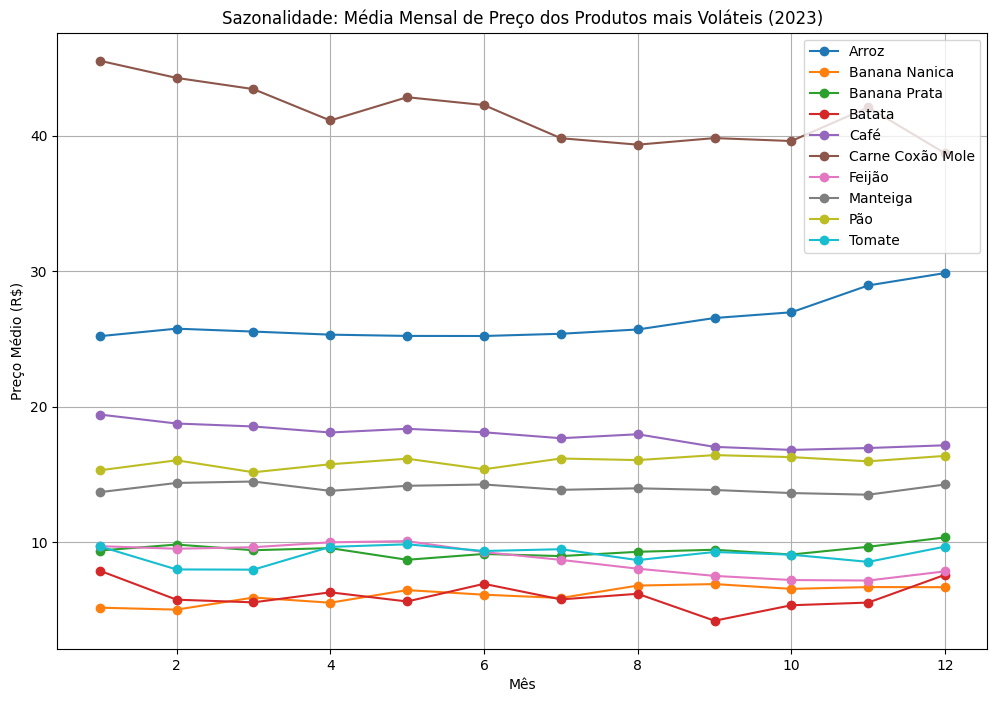

In [ ]:
df['Data_Coleta'] = pd.to_datetime(df['Data_Coleta'])
df['Mes'] = df['Data_Coleta'].dt.month
df['Ano'] = df['Data_Coleta'].dt.year

df_2023 = df[df['Ano'] == 2023]

media_mensal_2023 = df_2023.groupby(['Produto', 'Mes'])['Preco'].mean().reset_index()

volatilidade_2023 = df_2023.groupby('Produto')['Preco'].std().reset_index().rename(columns={'Preco': 'Volatilidade'})

top_10_volateis_2023 = volatilidade_2023.sort_values(by='Volatilidade', ascending=False).head(10)

top_10_volateis_2023 = top_10_volateis_2023.sort_values(by='Produto')

print("Top 10 produtos com maior volatilidade de preço (2023):")
print(top_10_volateis_2023)

plt.figure(figsize=(12, 8))

for produto in top_10_volateis_2023['Produto']:
    dados_produto = media_mensal_2023[media_mensal_2023['Produto'] == produto]
    plt.plot(dados_produto['Mes'], dados_produto['Preco'], marker='o', label=produto)

plt.title('Sazonalidade: Média Mensal de Preço dos Produtos mais Voláteis (2023)')
plt.xlabel('Mês')
plt.ylabel('Preço Médio (R$)')
plt.legend()
plt.grid(True)
plt.show()


Top 10 produtos com maior volatilidade de preço (2024):
             Produto  Volatilidade
0              Arroz      3.633230
2      Banana Nanica      1.915499
3       Banana Prata      2.454785
4             Batata      2.743020
5               Café      3.890016
6   Carne Coxão Mole      6.568964
8             Feijão      1.542079
10          Manteiga      2.844872
11               Pão      1.527755
12            Tomate      3.170096


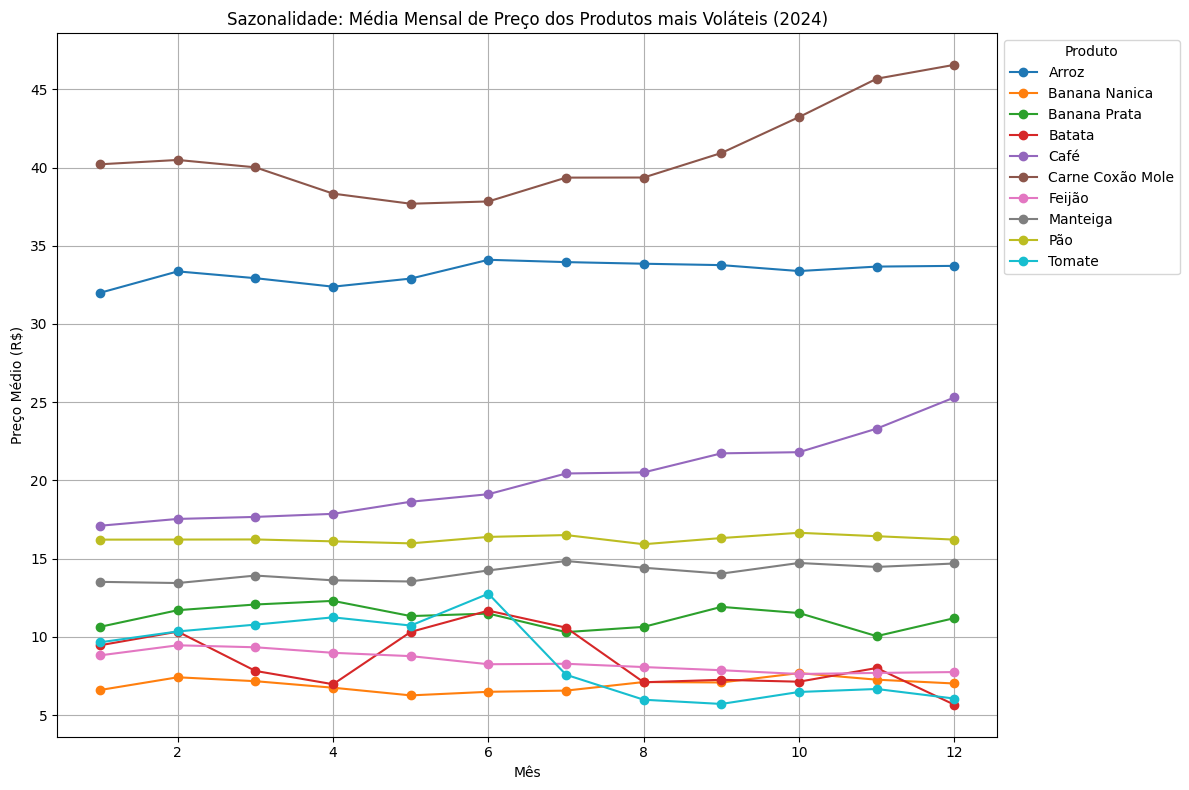

In [ ]:
# Converter a coluna de data e extrair mês e ano
df['Data_Coleta'] = pd.to_datetime(df['Data_Coleta'])
df['Mes'] = df['Data_Coleta'].dt.month
df['Ano'] = df['Data_Coleta'].dt.year

# Filtrar apenas os dados do ano de 2024
df_2024 = df[df['Ano'] == 2024]

# Calcular média mensal do preço por produto em 2024
media_mensal_2024 = df_2024.groupby(['Produto', 'Mes'])['Preco'].mean().reset_index()

# Calcular volatilidade (desvio padrão) por produto em 2024
volatilidade_2024 = df_2024.groupby('Produto')['Preco'].std().reset_index().rename(columns={'Preco': 'Volatilidade'})

# Selecionar os 10 produtos mais voláteis em 2024
top_10_volateis_2024 = volatilidade_2024.sort_values(by='Volatilidade', ascending=False).head(10)

# Ordenar os produtos em ordem alfabética
top_10_volateis_2024 = top_10_volateis_2024.sort_values(by='Produto')

print("Top 10 produtos com maior volatilidade de preço (2024):")
print(top_10_volateis_2024)

# Plotar a sazonalidade média mensal para esses produtos (2024)
plt.figure(figsize=(12, 8))

for produto in top_10_volateis_2024['Produto']:
    dados_produto = media_mensal_2024[media_mensal_2024['Produto'] == produto]
    plt.plot(dados_produto['Mes'], dados_produto['Preco'], marker='o', label=produto)

plt.title('Sazonalidade: Média Mensal de Preço dos Produtos mais Voláteis (2024)')
plt.xlabel('Mês')
plt.ylabel('Preço Médio (R$)')
plt.legend(title='Produto', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.tight_layout()
plt.show()

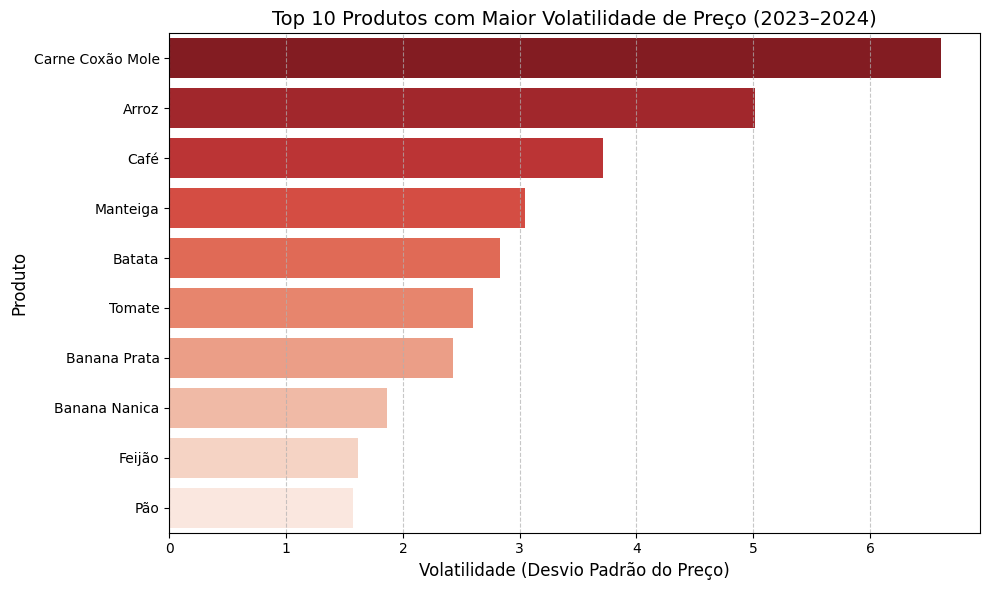

In [ ]:
df['Data_Coleta'] = pd.to_datetime(df['Data_Coleta'])
df['Ano'] = df['Data_Coleta'].dt.year
df_23_24 = df[df['Ano'].isin([2023, 2024])]

volatilidade_23_24 = df_23_24.groupby('Produto')['Preco'].std().reset_index()
volatilidade_23_24 = volatilidade_23_24.rename(columns={'Preco': 'Volatilidade'})

top_volateis = volatilidade_23_24.sort_values(by='Volatilidade', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_volateis,
    y='Produto',
    x='Volatilidade',
    palette='Reds_r'
)

plt.title('Top 10 Produtos com Maior Volatilidade de Preço (2023–2024)', fontsize=14)
plt.xlabel('Volatilidade (Desvio Padrão do Preço)', fontsize=12)
plt.ylabel('Produto', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
def categorizar_produto(produto):
    produto = produto.lower().strip()

    categorias = {
        'Grãos e Cereais': ['arroz', 'feijão', 'feijao', 'farinha', 'macarrão'],
        'Açúcar e Condimentos': ['açúcar', 'acucar', 'óleo', 'oleo', 'café', 'cafe'],
        'Carnes': ['carne acem', 'carne coxão mole', 'carne coxao mole', 'carne pernil', 'frango peito', 'frango sobrecoxa'],
        'Laticínios e Ovos': ['leite', 'manteiga', 'ovo'],
        'Pães e Massas': ['pão', 'pao', 'macarrão'],
        'Frutas': ['banana nanica', 'banana prata'],
        'Vegetais e Hortifruti': ['batata', 'tomate']
    }

    for categoria, palavras_chave in categorias.items():
        if any(p in produto for p in palavras_chave):
            return categoria

    return 'Outros'

df['Categoria'] = df['Produto'].apply(categorizar_produto)


In [ ]:
df_categoria_mercado = df.groupby(['Categoria', 'Estab'])['Preco'].mean().reset_index()


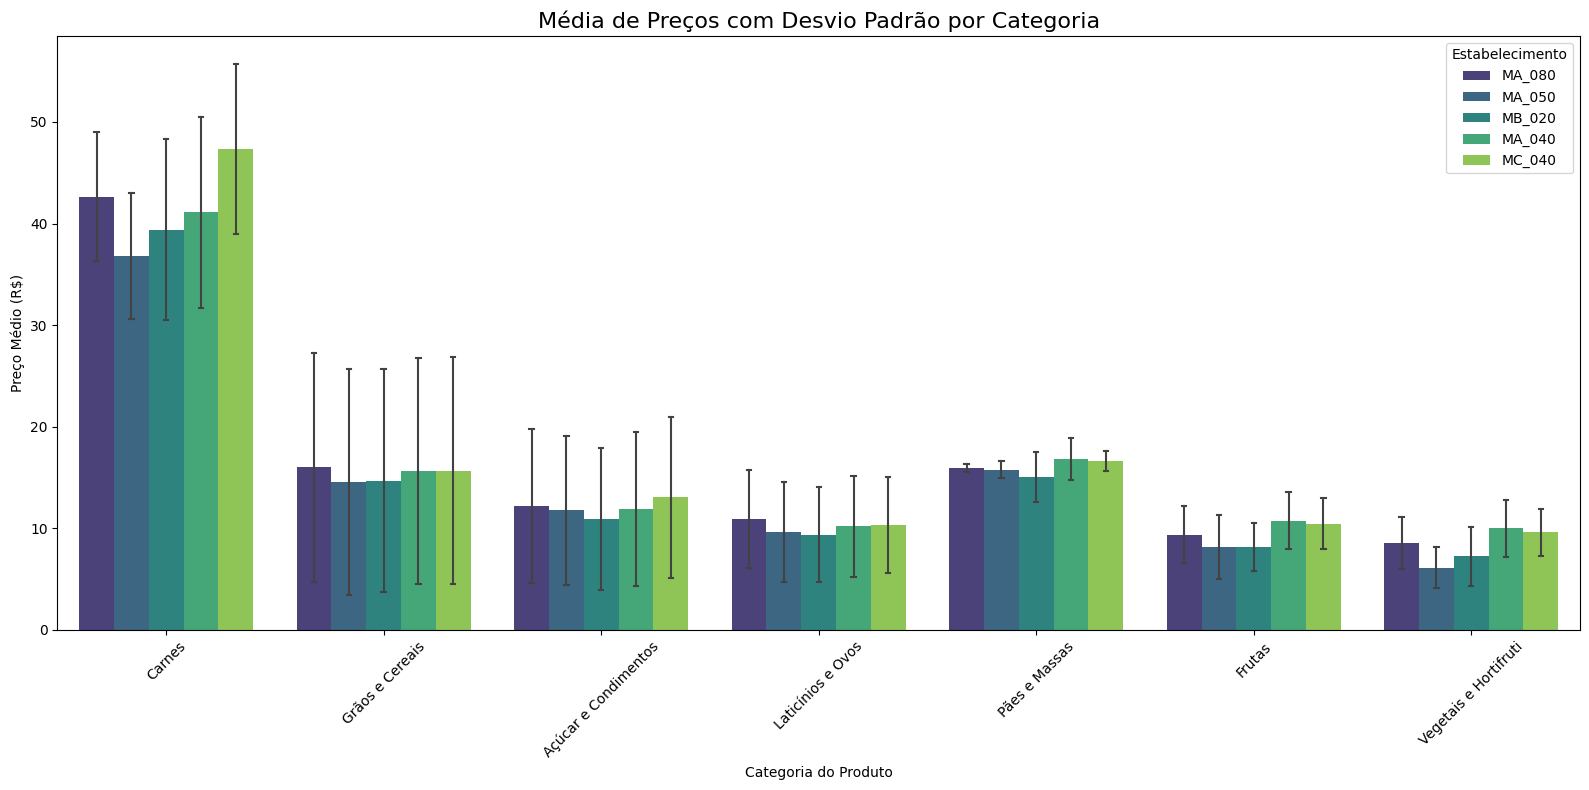

In [ ]:
top5_mercados = df['Estab'].value_counts().head(5).index.tolist()
df_filtrado = df[df['Estab'].isin(top5_mercados)]

plt.figure(figsize=(16, 8))
sns.barplot(data=df_filtrado, x='Categoria', y='Preco', hue='Estab',
           ci='sd', capsize=0.1, errwidth=1.5, palette="viridis")
plt.title('Média de Preços com Desvio Padrão por Categoria', fontsize=16)
plt.xlabel('Categoria do Produto')
plt.ylabel('Preço Médio (R$)')
plt.legend(title='Estabelecimento')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Produto
Café        3434
Arroz       3335
Manteiga    3019
Feijão      2965
Leite       2843
Farinha     2701
Óleo        2055
Açúcar      2050
Tomate       838
Batata       830
Name: count, dtype: int64


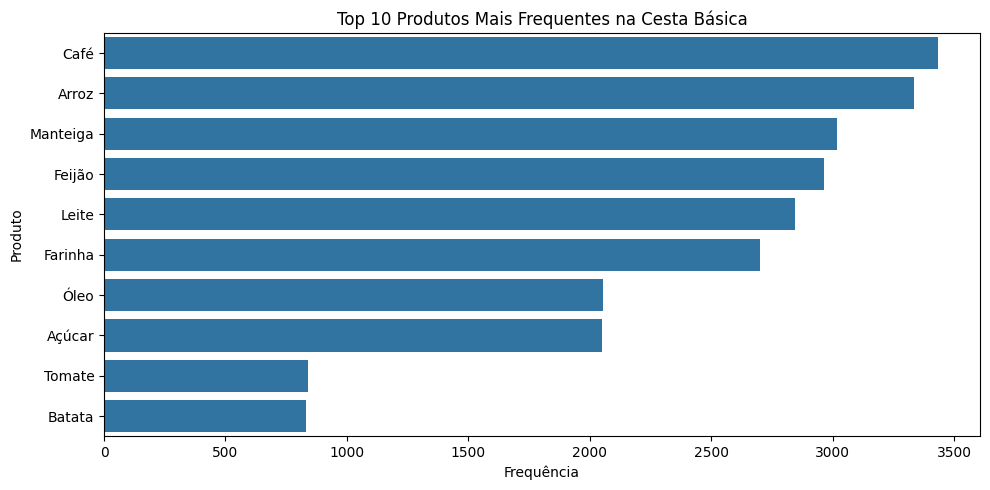

In [ ]:
top10_produtos = df['Produto'].value_counts().head(10)
print(top10_produtos)

plt.figure(figsize=(10,5))
sns.barplot(x=top10_produtos.values, y=top10_produtos.index, orient='h')
plt.title('Top 10 Produtos Mais Frequentes na Cesta Básica')
plt.xlabel('Frequência')
plt.ylabel('Produto')
plt.tight_layout()
plt.show()

In [ ]:
estabelecimento_mais_popular = df['Estab'].value_counts().idxmax()
print(f"Estabelecimento mais popular: {estabelecimento_mais_popular}")

Estabelecimento mais popular: MA_080


In [ ]:
def normalizar(texto):
    texto = texto.lower()
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    texto = texto.strip()
    return texto

estabelecimento_mais_popular = df['Estab'].value_counts().idxmax()
print(f"Estabelecimento mais popular: {estabelecimento_mais_popular}")

df_estab = df[df['Estab'] == estabelecimento_mais_popular].copy()

df_estab['Produto_Normalizado'] = df_estab['Produto'].apply(normalizar)

cesta_basica_expandida = [
    'cafe', 'arroz', 'manteiga', 'feijao', 'leite',
    'farinha', 'oleo', 'acucar', 'tomate', 'batata'
]

df_cesta = df_estab[df_estab['Produto_Normalizado'].apply(
    lambda x: any(produto in x for produto in cesta_basica_expandida)
)]

df_media = df_cesta.groupby(['AnoMes', 'Produto'])['Preco'].mean().reset_index()

df_pivot = df_media.pivot(index='AnoMes', columns='Produto', values='Preco')

df_pivot['Custo_Cesta_Basica'] = df_pivot.sum(axis=1)

media_total = df_pivot['Custo_Cesta_Basica'].mean()

print(f"\nMédia total da cesta básica no estabelecimento {estabelecimento_mais_popular}: R$ {media_total:.2f}")
print("\nCusto mensal da cesta básica:")
print(df_pivot['Custo_Cesta_Basica'])


Estabelecimento mais popular: MA_080

Média total da cesta básica no estabelecimento MA_080: R$ 109.11

Custo mensal da cesta básica:
AnoMes
2022-09    107.688333
2022-10    111.323667
2022-11    109.822667
2022-12    112.341667
2023-01    112.980000
2023-02    101.219167
2023-03    111.558333
2023-04    110.902500
2023-05    111.211667
2023-06    112.566667
2023-07    111.746667
2023-08    113.280000
2023-09    106.644841
2023-10    108.781667
2023-11    112.348333
2023-12    112.125000
2024-01    114.615000
2024-02    121.115000
2024-03    122.134167
2024-04    121.856111
2024-05    124.797778
2024-06    131.824405
2024-07    120.110000
2024-08    112.550000
2024-09    121.366667
2024-10    117.475000
2024-11    120.166667
2024-12    121.891667
2025-01     17.990000
2025-02     17.900000
2025-03    129.944167
Freq: M, Name: Custo_Cesta_Basica, dtype: float64


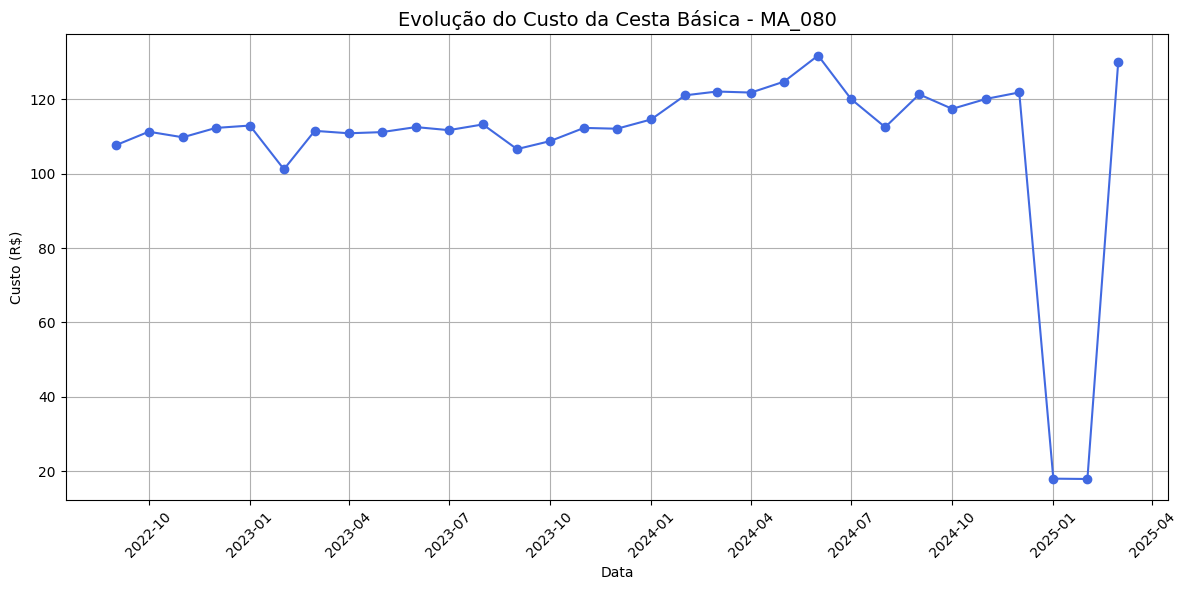

In [ ]:
df_pivot = df_pivot.copy()
df_pivot.index = df_pivot.index.to_timestamp()

plt.figure(figsize=(12, 6))
plt.plot(df_pivot.index, df_pivot['Custo_Cesta_Basica'], marker='o', color='royalblue')

plt.title(f'Evolução do Custo da Cesta Básica - {estabelecimento_mais_popular}', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Custo (R$)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
produtos_comparar = ['arroz', 'macarrao', 'tomate', 'banana nanica']

df_ma080 = df[df['Estab'] == 'MA_080'].copy()

df_ma080['Produto'] = df_ma080['Produto'].apply(normalizar)

df_filtrados = df_ma080[df_ma080['Produto'].isin(produtos_comparar)]

precos_medios = df_filtrados.groupby('Produto')['Preco'].mean()

print("Preço médio no MA_080:")
print(precos_medios)


Preço médio no MA_080:
Produto
arroz            30.630652
banana nanica     7.614138
macarrao          4.590000
tomate            9.714118
Name: Preco, dtype: float64


In [ ]:
cesta_basica_expandida = [
    'cafe', 'macarrao', 'manteiga', 'feijao', 'leite',
    'farinha', 'oleo', 'acucar', 'banana nanica', 'batata'
]

df_cesta = df_estab[df_estab['Produto_Normalizado'].apply(
    lambda x: any(produto in x for produto in cesta_basica_expandida)
)]

df_media = df_cesta.groupby(['AnoMes', 'Produto_Normalizado'])['Preco'].mean().reset_index()

df_pivot = df_media.pivot(index='AnoMes', columns='Produto_Normalizado', values='Preco')

df_pivot['Custo_Cesta_Basica'] = df_pivot.sum(axis=1)

media_total = df_pivot['Custo_Cesta_Basica'].mean()

print(f"\nMédia total da cesta básica no estabelecimento {estabelecimento_mais_popular} com as substituições: R$ {media_total:.2f}")
print("\nCusto mensal da cesta básica com as substituições:")
print(df_pivot['Custo_Cesta_Basica'])



Média total da cesta básica no estabelecimento MA_080 com as substituições: R$ 77.38

Custo mensal da cesta básica com as substituições:
AnoMes
2022-09    75.458333
2022-10    76.343667
2022-11    73.396000
2022-12    74.611667
2023-01    75.333333
2023-02    65.572500
2023-03    82.568333
2023-04    80.912500
2023-05    81.221667
2023-06    80.826667
2023-07    79.556667
2023-08    81.290000
2023-09    75.975952
2023-10    77.385000
2023-11    78.518333
2023-12    73.645000
2024-01    81.185000
2024-02    86.025000
2024-03    87.146667
2024-04    82.866111
2024-05    86.418889
2024-06    88.167738
2024-07    85.460000
2024-08    85.560000
2024-09    86.043333
2024-10    86.235000
2024-11    88.426667
2024-12    90.101667
2025-01    17.990000
2025-02    17.900000
2025-03    96.566667
Freq: M, Name: Custo_Cesta_Basica, dtype: float64


In [ ]:
cesta_basica_expandida = [
    'cafe', 'macarrao', 'manteiga', 'feijao', 'leite',
    'farinha', 'oleo', 'acucar', 'banana nanica', 'batata'
]

df_cesta = df_estab[df_estab['Produto_Normalizado'].apply(
    lambda x: any(produto in x for produto in cesta_basica_expandida)
)]

df_marcas = df_cesta.groupby(['Produto_Normalizado', 'Marca_Padronizada', 'AnoMes'])['Preco'].mean().reset_index()

resultados = []

for produto in cesta_basica_expandida:
    produto_df = df_marcas[df_marcas['Produto_Normalizado'].str.contains(produto)]

    if produto_df.empty:
        continue

    for marca, grupo in produto_df.groupby('Marca_Padronizada'):
        grupo = grupo.sort_values('AnoMes')

        preco_inicial = grupo['Preco'].iloc[0]
        preco_final = grupo['Preco'].iloc[-1]
        aumento = preco_final - preco_inicial

        resultados.append({
            'Produto': produto,
            'Marca': marca,
            'Primeiro_Preco_Coletado': preco_inicial,
            'Ultimo_Preco_Coletado': preco_final,
            'Aumento': aumento
        })

df_resultados = pd.DataFrame(resultados)

menor_aumento_por_produto = df_resultados.loc[
    df_resultados.groupby('Produto')['Aumento'].idxmin()
].reset_index(drop=True)

print("\nMarca com menor aumento de preço por produto:")
print(menor_aumento_por_produto)



Marca com menor aumento de preço por produto:
         Produto                Marca  Primeiro_Preco_Coletado  \
0         acucar            caravelas                     4.79   
1  banana nanica                    0                     6.99   
2         batata                    0                     5.29   
3           cafe                 fort                    17.99   
4        farinha  famiglia venturelli                     6.99   
5         feijao        grao de campo                    10.29   
6          leite               italac                     5.29   
7       macarrao           dona benta                     4.59   
8       manteiga             catupiry                     5.89   
9           oleo              cocamar                     8.86   

   Ultimo_Preco_Coletado  Aumento  
0                   4.79     0.00  
1                   4.99    -2.00  
2                   3.99    -1.30  
3                  17.99     0.00  
4                   5.99    -1.00  
5         

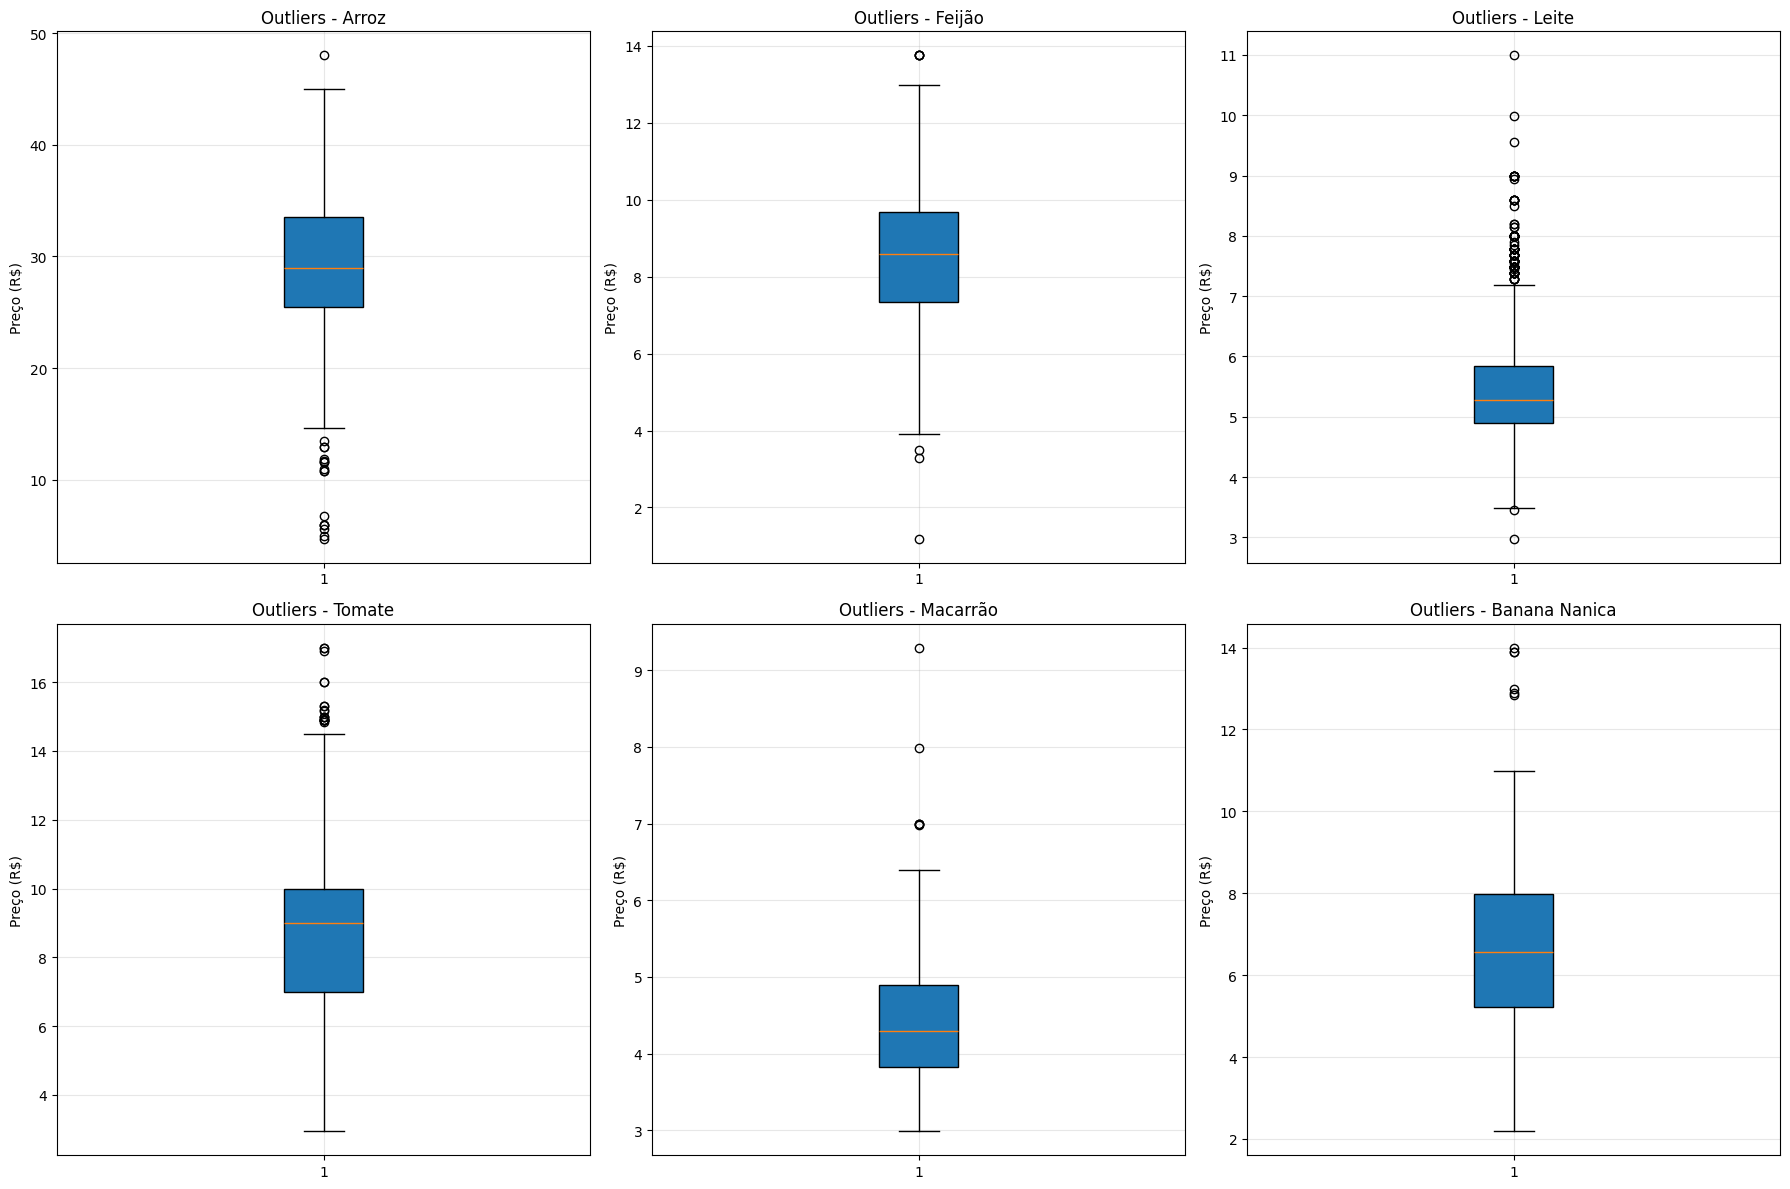

In [ ]:
produtos_destaque = ['Arroz', 'Feijão', 'Leite', 'Tomate', 'Macarrão', 'Banana Nanica']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, produto in enumerate(produtos_destaque):

    dados_produto = df[df['Produto'] == produto]

    if not dados_produto.empty:
        axes[i].boxplot(dados_produto['Preco'], patch_artist=True)
        axes[i].set_title(f'Outliers - {produto}')
        axes[i].set_ylabel('Preço (R$)')
        axes[i].grid(True, alpha=0.3)
    else:
        axes[i].text(0.5, 0.5, f'Sem dados\npara {produto}',
                     ha='center', va='center', fontsize=12)
        axes[i].set_title(f'{produto} (vazio)')
        axes[i].axis('off')

if len(produtos_destaque) < len(axes):
    for j in range(len(produtos_destaque), len(axes)):
        axes[j].remove()

plt.tight_layout()
plt.show()


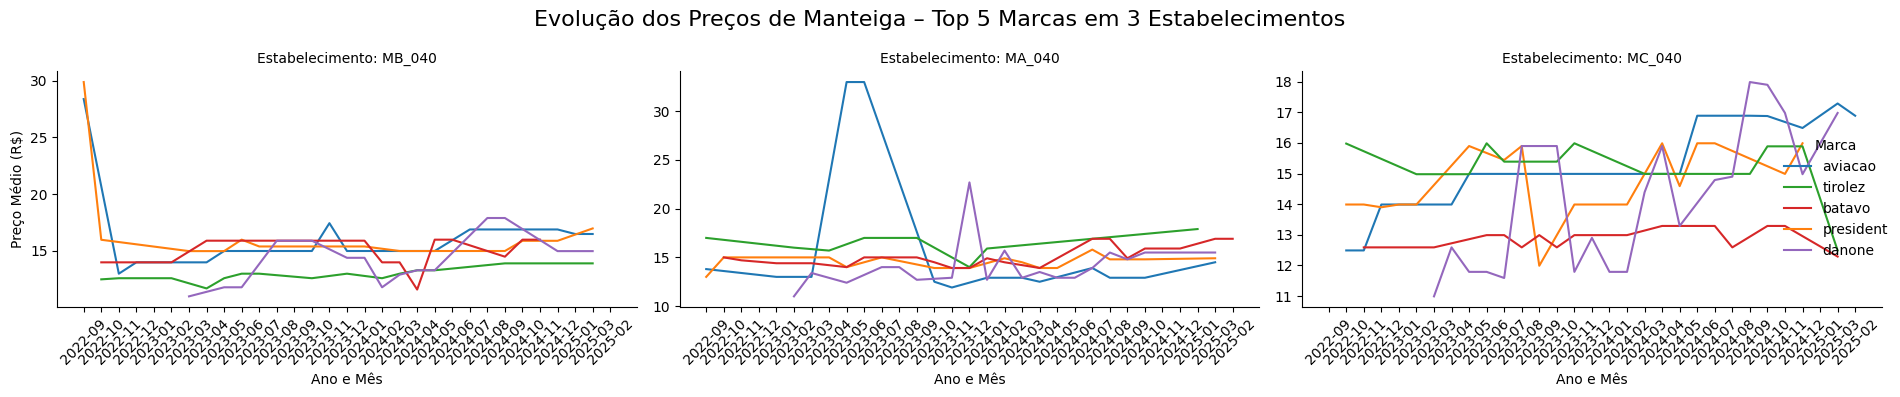

In [ ]:
df['Data_Coleta'] = pd.to_datetime(df['Data_Coleta'])
df['AnoMes'] = df['Data_Coleta'].dt.to_period('M').astype(str)

produto_escolhido = 'Manteiga'

df_produto = df[df['Produto'] == produto_escolhido]

top_marcas = df_produto['Marca_Padronizada'].value_counts().nlargest(5).index.tolist()

top_estabs = df_produto['Estab'].value_counts().nlargest(3).index.tolist()

df_filtrado = df_produto[
    df_produto['Marca_Padronizada'].isin(top_marcas) &
    df_produto['Estab'].isin(top_estabs)
]

preco_mensal = df_filtrado.groupby(['AnoMes', 'Marca_Padronizada', 'Estab'])['Preco'].mean().reset_index()

g = sns.FacetGrid(
    preco_mensal,
    col='Estab',
    col_wrap=3,
    height=4,
    aspect=1.5,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x='AnoMes',
    y='Preco',
    hue='Marca_Padronizada'
)

g.set_titles(col_template='Estabelecimento: {col_name}')
g.set_axis_labels('Ano e Mês', 'Preço Médio (R$)')
g.add_legend(title='Marca')
for ax in g.axes.flatten():
    ax.tick_params(labelbottom=True)
    ax.tick_params(axis='x', rotation=45)
plt.subplots_adjust(top=0.92)
g.fig.suptitle(f'Evolução dos Preços de {produto_escolhido} – Top 5 Marcas em 3 Estabelecimentos', fontsize=16)
plt.tight_layout()
plt.show()
